In [1]:
import numpy as np

def check_binary_lut(filepath, expected_elements=None):
    try:
        data = np.fromfile(filepath, dtype=np.float32)
        if len(data) % 6 != 0:
            raise ValueError("The binary .lut file does not contain a multiple of 6 floats per crystal.")
        num_crystals = len(data) // 6
        print(f"✅ Total crystals found: {num_crystals}")
        if expected_elements is not None and num_crystals != expected_elements:
            print(f"❌ Mismatch with expected number of elements: {expected_elements}")
        else:
            print("✅ Number of elements matches expectation.")

        # Check orientation vectors norm
        vectors = data.reshape((-1, 6))[:, 3:6]
        norms = np.linalg.norm(vectors, axis=1)
        if not np.allclose(norms, 1.0, atol=1e-2):
            print("⚠️ Warning: Some orientation vectors are not unit length (||v|| != 1).")
        else:
            print("✅ Orientation vectors look normalized.")
    except Exception as e:
        print(f"❌ Error reading binary LUT: {e}")


In [2]:
def print_lut_preview(filepath, num_crystals=5):
    # read the whole file
    data = np.fromfile(filepath, dtype=np.float32)

    if len(data) % 6 != 0:
        raise ValueError("File length is not divisible by 6. Each crystal should have 6 float32 values.")

    data = data.reshape((-1, 6))
    print(f"Total crystals: {data.shape[0]}\n")
    print(f"Showing first {num_crystals} crystals:")

    for i in range(min(num_crystals, data.shape[0])):
        pos = data[i, 0:3]
        ori = data[i, 3:6]
        print(f"Crystal {i}:")
        print(f"  Position (x, y, z): {pos}")
        print(f"  Orientation (vx, vy, vz): {ori}")
        print()


### csv data to cdh

In [3]:
import struct

def parse_cdh_for_event_structure(cdh_path):
    """
    Parse the .cdh header to determine the binary structure of the .cdf file.
    According to the CASToR documentation table: 
    Time -> Correction/TOF Factors (FLTNBDATA) -> Crystal IDs.
    """
    with open(cdh_path, "r") as f:
        lines = f.readlines()

    # 1. Start with Timestamp (uint32_t)
    fields = [("time", "I")]
    total_size = 4

    # Load header flags into a dictionary
    flags = {line.split(":")[0].strip(): line.split(":")[1].strip() for line in lines if ":" in line}
    
    def add_field(name, fmt, size):
        nonlocal total_size
        fields.append((name, fmt))
        total_size += size

    # 2. Add Floating point data (FLTNBDATA) BEFORE Crystal IDs
    # Following the order in Table 3: a -> s -> r -> n -> TOF -> TOFev
    if flags.get("Attenuation correction flag", "0") == "1":
        add_field("attenuation", "f", 4)
    if flags.get("Scatter correction flag", "0") == "1":
        add_field("scatter", "f", 4)
    if flags.get("Random correction flag", "0") == "1":
        add_field("random", "f", 4)
    if flags.get("Normalization correction flag", "0") == "1":
        add_field("normalization", "f", 4)
    
    # TOF fields
    if flags.get("TOF information flag", "0") == "1":
        add_field("tof", "f", 4)
        if flags.get("Per event TOF resolution flag", "0") == "1":
            add_field("tof_resolution", "f", 4)

    # 3. Add Crystal IDs (uint32_t) at the end of the mandatory/optional block
    add_field("crystal1", "I", 4)
    add_field("crystal2", "I", 4)

    # Generate format string (e.g., "<IfII")
    format_string = "<" + "".join(fmt for _, fmt in fields)

    return fields, format_string, total_size

def read_castor_event_auto(file, i, format_string, event_size):
    file.seek(i * event_size)
    data = file.read(event_size)
    if len(data) < event_size:
        return None
    values = struct.unpack(format_string, data)
    return values

def preview_castor_cdf_auto(cdf_path, cdh_path, num_events=5):
    fields, fmt, evt_size = parse_cdh_for_event_structure(cdh_path)
    print(f"Detected structure: {fields}")
    print(f"Total event size: {evt_size} bytes")

    with open(cdf_path, "rb") as f:
        for i in range(num_events):
            result = read_castor_event_auto(f, i, fmt, evt_size)
            if result is None:
                break
            print(f"Event {i}:")
            for (name, _), val in zip(fields, result):
                print(f"  {name}: {val}")
            print()


### new data for test

In [4]:
new_config_path =  "/Users/yuema/MyCode/LXePETSim/LXePETSim/castor_reconstruction/castor_configs"
new_data_path = "/Users/yuema/MyCode/LXePETSim/LXePETSim/castor_reconstruction/castor_data"

new_config_lut = "{}/philips_vereos_virtual_crystals_binary.lut".format(new_config_path)
new_config_header = "{}/philips_vereos_virtual_crystals.hscan".format(new_config_path)
# test the lut file that we generated
print_lut_preview(new_config_lut, num_crystals=5)

Total crystals: 23040

Showing first 5 crystals:
Crystal 0:
  Position (x, y, z): [-385.55225  -67.98326  -78.5    ]
  Orientation (vx, vy, vz): [0.9848077  0.17364818 0.        ]

Crystal 1:
  Position (x, y, z): [-384.78772  -72.18485  -78.5    ]
  Orientation (vx, vy, vz): [0.98285496 0.18438022 0.        ]

Crystal 2:
  Position (x, y, z): [-383.97745  -76.37786  -78.5    ]
  Orientation (vx, vy, vz): [0.98078525 0.19509032 0.        ]

Crystal 3:
  Position (x, y, z): [-383.12146   -80.561775  -78.5     ]
  Orientation (vx, vy, vz): [0.9785989  0.20577721 0.        ]

Crystal 4:
  Position (x, y, z): [-382.21988  -84.73611  -78.5    ]
  Orientation (vx, vy, vz): [0.976296   0.21643962 0.        ]



In [5]:
# load csv and convert 

import glob
prefix = "coincidence_LXe_src0.0cm"
all_input_files = glob.glob("/Users/yuema/MyCode/LXePETSim/LXePETSim/PET_example/output_radius_plot/*coincidence_LXe_src0.0cm*.csv")
all_input_files

['/Users/yuema/MyCode/LXePETSim/LXePETSim/PET_example/output_radius_plot/coincidence_LXe_src0.0cm.csv']

In [9]:
import pandas as pd 

from scipy.spatial import cKDTree

lut_df = data = np.fromfile(new_config_lut, dtype=np.float32)
lut_df = lut_df.reshape((-1, 6))
# assign column names, index is crystal_id
lut_df = pd.DataFrame(lut_df, columns=["x", "y", "z", "vx", "vy", "vz"])
# add a column for crystal_id
lut_df.index.name = "crystal_id"
lut_df.reset_index(inplace=True)

# Build KDTree for quick nearest-neighbor lookup
crystal_pos = lut_df[["x", "y", "z"]].values
tree = cKDTree(crystal_pos)

    
def write_castor_header(output_path, data_file_name, num_events, 
                        is_tof=False, tof_res_ps=110.0, measurement_range_ps=3000.0):
    """
    Write a flexible CASToR header file (.cdh).
    measurement_range_ps: The total search window for TOF (usually > FOV_diameter / c).
    """
    with open(output_path, "w") as f:
        # Basic Setup
        f.write(f"Data filename: {data_file_name}\n")
        f.write(f"Number of events: {num_events}\n")
        f.write("Data mode: list-mode\n")
        f.write("Data type: PET\n")
        f.write("Scanner name: PET_PHILIPS_VEREOS\n")
        f.write("Start time (s): 0\n")
        f.write("Duration (s): 10\n")
        
        # TOF Configuration
        if is_tof:
            f.write("TOF information flag: 1\n")
            # The full width of the TOF acquisition window in ps
            f.write(f"List TOF measurement range (ps): {measurement_range_ps}\n")
            # TOF resolution (FWHM) in ps
            f.write(f"TOF resolution (ps): {tof_res_ps}\n")
        else:
            f.write("TOF information flag: 0\n")
        
        # Mandatory Flags (Set to 0/None for this simple case)
        f.write("Attenuation correction flag: 0\n")
        f.write("Normalization correction flag: 0\n")
        f.write("Scatter correction flag: 0\n")
        f.write("Random correction flag: 0\n")
        f.write("Maximum number of lines per event: 1\n")
        
    print(f"[CDH] Wrote {'TOF' if is_tof else 'Standard'} header with Measurement Range: {measurement_range_ps}ps")

"""
output_dir = "/Users/yuema/MyCode/castor_v3.2/LXePET/"
output_cdf = f"{output_dir}/{prefix}_tof_test.cdf"
output_cdh = f"{output_dir}/{prefix}_tof_test.cdh"

# merge events
t0 = 0
total_events = 0
with open(output_cdf, "wb") as f:
    for csv_path in all_input_files:
        coinc_data = pd.read_csv(csv_path)
        positions1 = np.vstack([
            coinc_data["globalPosX1"],
            coinc_data["globalPosY1"],
            coinc_data["globalPosZ1"]
        ]).T
        positions2 = np.vstack([
            coinc_data["globalPosX2"],
            coinc_data["globalPosY2"],
            coinc_data["globalPosZ2"]
        ]).T

        _, idx1 = tree.query(positions1)
        _, idx2 = tree.query(positions2)

        for i, (c1, c2) in enumerate(zip(idx1, idx2)):
            t = t0 + i
            data = struct.pack("<III", t, c1, c2)
            f.write(data)

        t0 += len(idx1)
        total_events += len(idx1)

print(f"[CDF] Final merged file written to {output_cdf} with {total_events} events")

# write header with correct event count
write_castor_header(
    output_cdh,
    data_file_name=str(output_cdf),
    num_events=total_events,
    is_tof=True,
)

new_data_header = str(output_cdh)
new_data_file   = str(output_cdf)
"""


'\noutput_dir = "/Users/yuema/MyCode/castor_v3.2/LXePET/"\noutput_cdf = f"{output_dir}/{prefix}_tof_test.cdf"\noutput_cdh = f"{output_dir}/{prefix}_tof_test.cdh"\n\n# merge events\nt0 = 0\ntotal_events = 0\nwith open(output_cdf, "wb") as f:\n    for csv_path in all_input_files:\n        coinc_data = pd.read_csv(csv_path)\n        positions1 = np.vstack([\n            coinc_data["globalPosX1"],\n            coinc_data["globalPosY1"],\n            coinc_data["globalPosZ1"]\n        ]).T\n        positions2 = np.vstack([\n            coinc_data["globalPosX2"],\n            coinc_data["globalPosY2"],\n            coinc_data["globalPosZ2"]\n        ]).T\n\n        _, idx1 = tree.query(positions1)\n        _, idx2 = tree.query(positions2)\n\n        for i, (c1, c2) in enumerate(zip(idx1, idx2)):\n            t = t0 + i\n            data = struct.pack("<III", t, c1, c2)\n            f.write(data)\n\n        t0 += len(idx1)\n        total_events += len(idx1)\n\nprint(f"[CDF] Final merged file 

In [16]:
import numpy as np
import pandas as pd
import struct
import glob

def convert_csv_to_castor_cdf(csv_file_list, output_cdf_path, tree, is_tof=False):
    """
    Convert OpenGate coincidence CSV files to CASToR binary (.cdf) format.
    Uses ID-based sorting to ensure TOF symmetry for reconstruction.
    """
    # Format according to CASToR Table 3: Time (I), TOF (f), ID1 (I), ID2 (I)
    pack_format = "<IfII" if is_tof else "<III"
    
    t0 = 0
    total_events = 0

    print(f"Starting conversion: TOF={is_tof}, Format='{pack_format}'")

    with open(output_cdf_path, "wb") as f:
        for csv_path in csv_file_list:
            coinc_data = pd.read_csv(csv_path)
            
            # 1. Get raw Crystal IDs from the KDTree
            pos1 = coinc_data[["globalPosX1", "globalPosY1", "globalPosZ1"]].values
            pos2 = coinc_data[["globalPosX2", "globalPosY2", "globalPosZ2"]].values
            _, idx1_raw = tree.query(pos1)
            _, idx2_raw = tree.query(pos2)
            
            # 2. Get raw times (in ns)
            t1_raw = coinc_data["time1"].values
            t2_raw = coinc_data["time2"].values

            # 3. Process each event
            for i in range(len(coinc_data)):
                timestamp_ms = int(t0 + i)
                
                # --- GEOMETRIC SORTING LOGIC ---
                # We force Crystal 1 to be the one with the smaller ID index.
                # This ensures TOF sign corresponds to geometric position.
                if idx1_raw[i] < idx2_raw[i]:
                    c1, c2 = idx1_raw[i], idx2_raw[i]
                    # TOF = (Time at Smaller ID) - (Time at Larger ID)
                    tof_ps = (t1_raw[i] - t2_raw[i]) * 1e3
                else:
                    c1, c2 = idx2_raw[i], idx1_raw[i]
                    # TOF = (Time at Smaller ID) - (Time at Larger ID)
                    # Since we swapped IDs, we must swap times.
                    tof_ps = (t2_raw[i] - t1_raw[i]) * 1e3
                # -------------------------------

                if is_tof:
                    # Pack: Time (I), TOF (f), ID1 (I), ID2 (I)
                    binary_record = struct.pack(pack_format, timestamp_ms, float(tof_ps), int(c1), int(c2))
                else:
                    binary_record = struct.pack(pack_format, timestamp_ms, int(c1), int(c2))
                
                f.write(binary_record)

            t0 += len(coinc_data)
            total_events += len(coinc_data)
            print(f"  Processed {len(coinc_data)} events from: {csv_path.split('/')[-1]}")

    print(f"\n[CDF] Success: '{output_cdf_path}' written.")
    print(f"[CDF] Total events: {total_events}")
    
    return total_events

In [23]:
is_tof = False
tof_res_ps = 174
tof_string = "tof" if is_tof else "wo_tof"

output_dir = "/Users/yuema/MyCode/castor_v3.2/LXePET_Radius_Compare"
output_cdf = f"{output_dir}/{prefix}_{tof_string}_test.cdf"
output_cdh = f"{output_dir}/{prefix}_{tof_string}_test.cdh"
new_data_header = str(output_cdh)
new_data_file   = str(output_cdf)

total_count = convert_csv_to_castor_cdf(
     all_input_files, 
     output_cdf, 
     tree, 
     is_tof=is_tof
 )

# write header with correct event count
write_castor_header(
    output_cdh,
    data_file_name=str(output_cdf),
    num_events=total_count,
    is_tof=is_tof, tof_res_ps=tof_res_ps, measurement_range_ps=3000.0
)



Starting conversion: TOF=False, Format='<III'
  Processed 37761 events from: coincidence_LXe_src0.0cm.csv

[CDF] Success: '/Users/yuema/MyCode/castor_v3.2/LXePET_Radius_Compare/coincidence_LXe_src0.0cm_wo_tof_test.cdf' written.
[CDF] Total events: 37761
[CDH] Wrote Standard header with Measurement Range: 3000.0ps


In [18]:
preview_castor_cdf_auto(new_data_file, new_data_header, num_events=5)

Detected structure: [('time', 'I'), ('tof', 'f'), ('crystal1', 'I'), ('crystal2', 'I')]
Total event size: 16 bytes
Event 0:
  time: 0
  tof: 135.20468139648438
  crystal1: 415
  crystal2: 22020

Event 1:
  time: 1
  tof: 54.79804229736328
  crystal1: 3011
  crystal2: 20001

Event 2:
  time: 2
  tof: -63.1718864440918
  crystal1: 1572
  crystal2: 20870

Event 3:
  time: 3
  tof: 64.97674560546875
  crystal1: 10582
  crystal2: 13745

Event 4:
  time: 4
  tof: -1.890912652015686
  crystal1: 6320
  crystal2: 16978



Reading /Users/yuema/MyCode/castor_v3.2/LXePET/coincidence_LXe_src0.0cm_tof_test.cdf for TOF analysis...
--- TOF Statistics ---
Total events processed: 37761
Mean TOF: -0.56 ps
Standard Deviation: 74.00 ps
Estimated FWHM: 174.26 ps


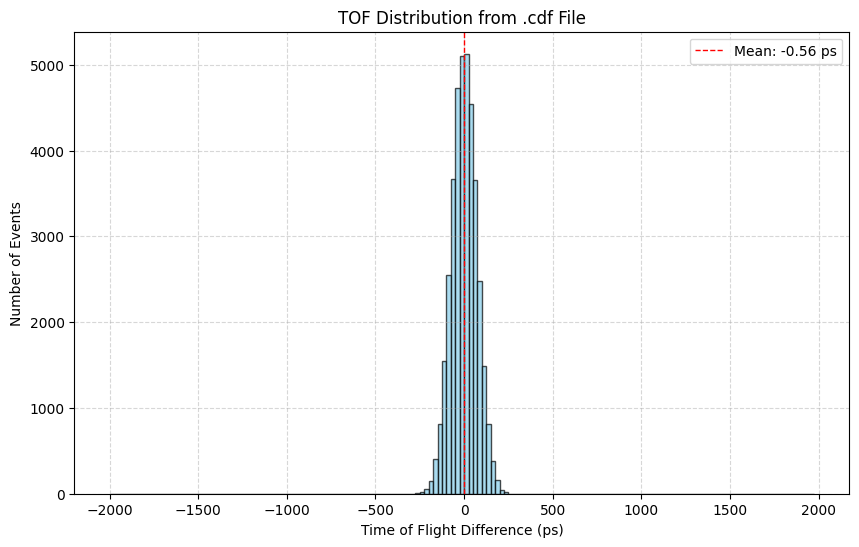

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import struct

def plot_castor_tof_distribution(cdf_path, cdh_path, num_events=None):
    """
    Read the binary .cdf file based on its .cdh header and plot the TOF distribution.
    """
    # 1. Get the structure using your previous function
    fields, fmt, evt_size = parse_cdh_for_event_structure(cdh_path)
    
    # Find the index of the 'tof' field in the unpacked tuple
    tof_idx = next((i for i, (name, _) in enumerate(fields) if name == 'tof'), None)
    
    if tof_idx is None:
        print("❌ Error: TOF information flag is not enabled in the header.")
        return

    tof_values = []
    
    print(f"Reading {cdf_path} for TOF analysis...")
    
    with open(cdf_path, "rb") as f:
        # If num_events is not specified, read the whole file
        content = f.read()
        total_records = len(content) // evt_size
        
        # Limit the number of events to process if requested
        n_to_read = total_records if num_events is None else min(num_events, total_records)
        
        for i in range(n_to_read):
            # Extract only the necessary chunk
            start = i * evt_size
            chunk = content[start : start + evt_size]
            values = struct.unpack(fmt, chunk)
            tof_values.append(values[tof_idx])

    tof_values = np.array(tof_values)

    # 2. Plotting
    plt.figure(figsize=(10, 6))
    plt.hist(tof_values, bins=np.arange(-2000,2000,25), color='skyblue', edgecolor='black', alpha=0.7)
    
    # Calculate statistics
    mean_val = np.mean(tof_values)
    std_val = np.std(tof_values)
    fwhm = 2.355 * std_val # Estimation of FWHM
    
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f} ps')
    
    plt.title("TOF Distribution from .cdf File")
    plt.xlabel("Time of Flight Difference (ps)")
    plt.ylabel("Number of Events")
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    print(f"--- TOF Statistics ---")
    print(f"Total events processed: {len(tof_values)}")
    print(f"Mean TOF: {mean_val:.2f} ps")
    print(f"Standard Deviation: {std_val:.2f} ps")
    print(f"Estimated FWHM: {fwhm:.2f} ps")
    
    plt.show()

# Usage:
plot_castor_tof_distribution(new_data_file, new_data_header)